In [10]:
import pandas as pd

df = pd.read_csv("C:/Users/MS994/Downloads/fds/depression_analysis_processed.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
df.info()

Shape: (805, 25)

Columns:
 ['timestamp', 'age', 'gender', 'stress', 'anxiety', 'sadness', 'overwhelmed', 'concentration', 'overthinking', 'mood_swings', 'tired', 'support', 'social', 'coping', 'wellbeing', 'sleep', 'emotional_score', 'cognitive_score', 'sleep_risk', 'physical_score', 'social_score', 'behavioral_score', 'drs_raw', 'drs', 'risk_level']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805 entries, 0 to 804
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         805 non-null    object 
 1   age               805 non-null    int64  
 2   gender            805 non-null    object 
 3   stress            805 non-null    int64  
 4   anxiety           805 non-null    int64  
 5   sadness           805 non-null    int64  
 6   overwhelmed       805 non-null    int64  
 7   concentration     805 non-null    int64  
 8   overthinking      805 non-null    int64  
 9   mood_swings 

In [11]:
#Data Quality
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

timestamp           0
age                 0
gender              0
stress              0
anxiety             0
sadness             0
overwhelmed         0
concentration       0
overthinking        0
mood_swings         0
tired               0
support             0
social              0
coping              0
wellbeing           0
sleep               0
emotional_score     0
cognitive_score     0
sleep_risk          0
physical_score      0
social_score        0
behavioral_score    0
drs_raw             0
drs                 0
risk_level          0
dtype: int64
Duplicates: 0


In [8]:
#UNIVARIATE ANALYSIS
#Target variable
print(df['risk_level'].value_counts())
print(df['risk_level'].value_counts(normalize=True)*100)

#balanced

risk_level
High        273
Low         268
Moderate    267
Name: count, dtype: int64
risk_level
High        33.787129
Low         33.168317
Moderate    33.044554
Name: proportion, dtype: float64


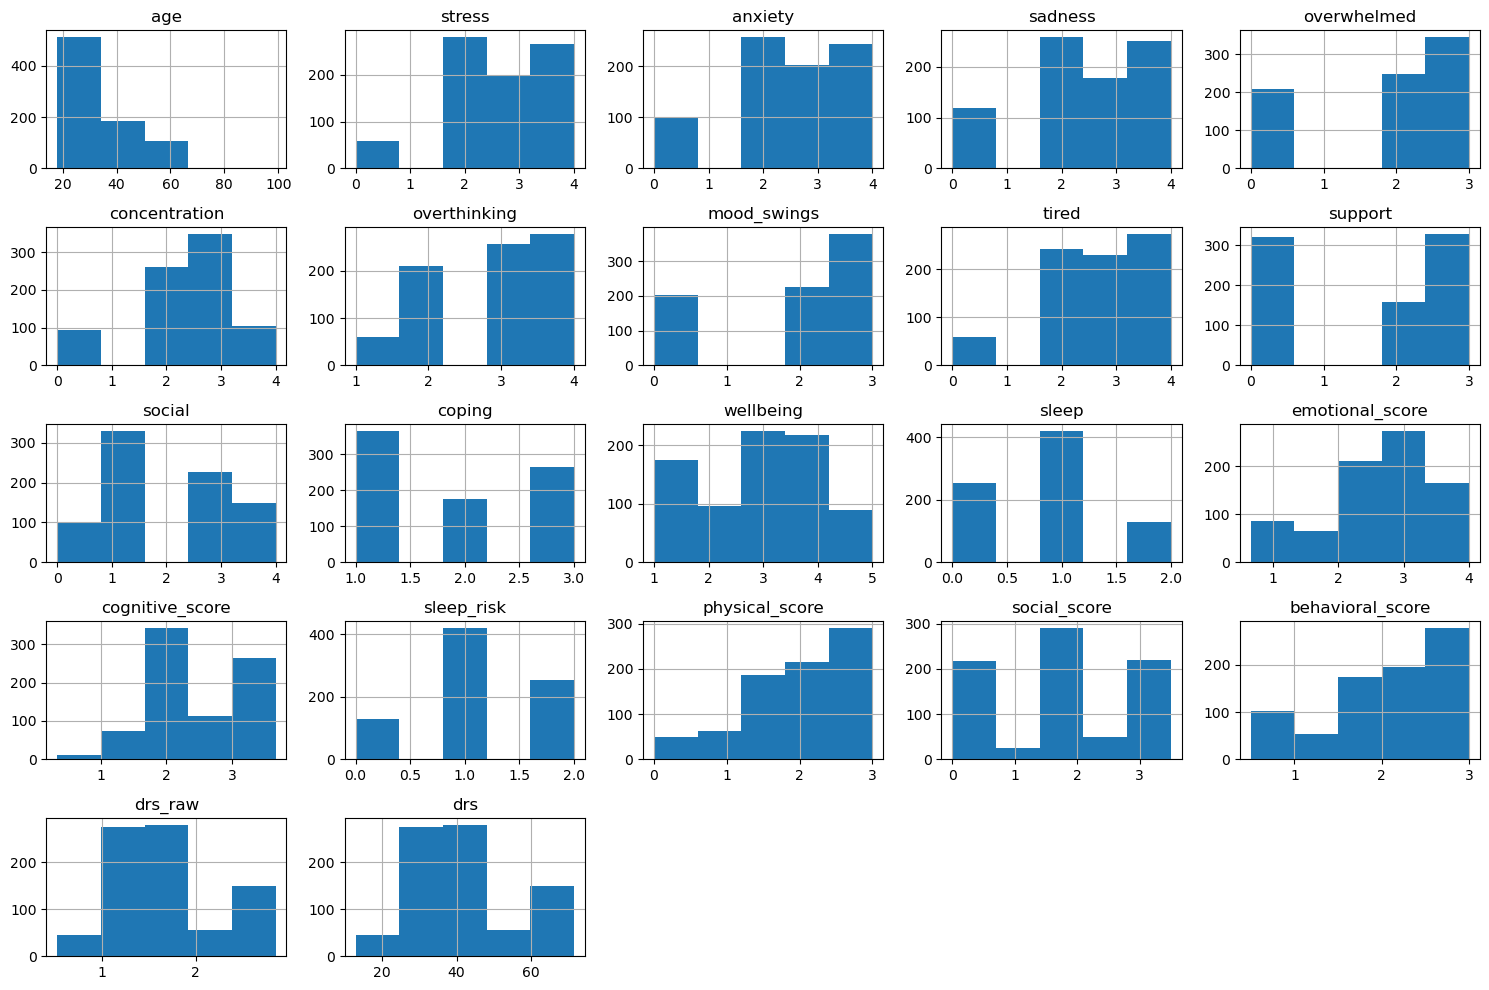

In [12]:
import matplotlib.pyplot as plt
#distribution of every feature
df.hist(figsize=(15,10), bins=5)
plt.tight_layout()
plt.show()

In [16]:
#mean 
df = df.drop(columns=['timestamp'], errors='ignore')
df.mean(numeric_only=True).sort_values(ascending=False)

drs                 42.983954
age                 32.606211
overthinking         2.935404
wellbeing            2.934161
tired                2.822360
stress               2.761491
emotional_score      2.638095
anxiety              2.607453
sadness              2.545342
concentration        2.454658
cognitive_score      2.432712
physical_score       1.988199
social               1.987578
mood_swings          1.967702
behavioral_score     1.921118
overwhelmed          1.908075
coping               1.874534
social_score         1.800000
drs_raw              1.719358
support              1.612422
sleep_risk           1.154037
sleep                0.845963
dtype: float64

In [17]:
#col analysis
for col in df.columns:
    print(f"\n{col}")
    print(df[col].value_counts())


age
age
20    44
21    42
22    42
25    39
19    38
24    38
18    37
29    37
27    36
26    35
23    34
28    27
30    24
38    17
52    16
35    16
41    15
37    14
32    14
54    14
59    13
47    13
56    13
57    12
49    12
60    12
39    12
45    11
48    11
31    11
46    11
51    10
40    10
33    10
36     9
44     9
43     9
55     8
50     8
42     6
34     5
53     5
58     5
99     1
Name: count, dtype: int64

gender
gender
Male                 335
Female               306
Prefer not to say    141
Non - binary          23
Name: count, dtype: int64

stress
stress
2    281
4    266
3    199
0     59
Name: count, dtype: int64

anxiety
anxiety
2    257
4    244
3    203
0    101
Name: count, dtype: int64

sadness
sadness
2    259
4    250
3    177
0    119
Name: count, dtype: int64

overwhelmed
overwhelmed
3    346
2    249
0    210
Name: count, dtype: int64

concentration
concentration
3    348
2    260
4    103
0     94
Name: count, dtype: int64

overthinking
overthinki

In [18]:
#Depression score
# First invert positive features
df['support_inv'] = 4 - df['support']
df['social_inv'] = 4 - df['social']
df['coping_inv'] = 3 - df['coping']
df['wellbeing_inv'] = 6 - df['wellbeing']

# Now compute final score
df['drs'] = (
    df['stress'] +
    df['anxiety'] +
    df['sadness'] +
    df['overwhelmed'] +
    df['concentration'] +
    df['overthinking'] +
    df['mood_swings'] +
    df['tired'] +
    df['sleep'] +
    df['support_inv'] +
    df['social_inv'] +
    df['coping_inv'] +
    df['wellbeing_inv']
)


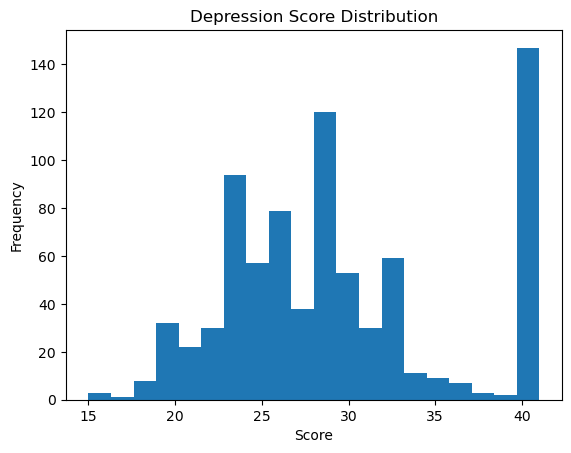

In [20]:
#check score dist
import matplotlib.pyplot as plt

plt.hist(df['drs'], bins=20)
plt.title("Depression Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()
#right skewed

In [21]:
#basic statistics
print(df['drs'].describe())

count    805.000000
mean      29.439752
std        6.625400
min       15.000000
25%       25.000000
50%       28.000000
75%       33.000000
max       41.000000
Name: drs, dtype: float64


In [23]:
#risk lev
print(df['risk_level'].value_counts(normalize=True) * 100)

risk_level
Low         40.496894
High        33.291925
Moderate    26.211180
Name: proportion, dtype: float64


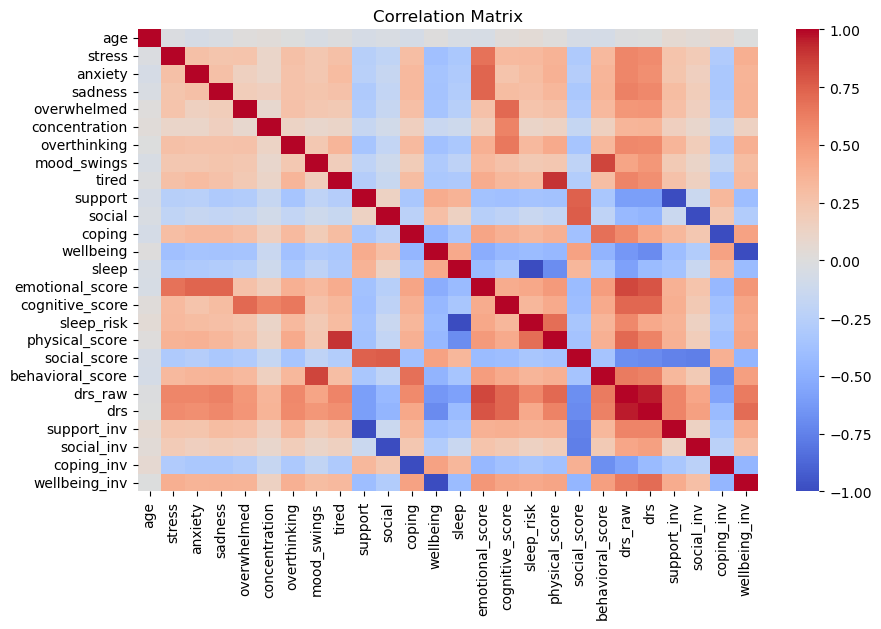

In [26]:
#bivariate
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [27]:
#mean score by risk level
df.groupby('risk_level').mean(numeric_only=True)

,age,stress,anxiety,sadness,overwhelmed,concentration,overthinking,mood_swings,tired,support,...,sleep_risk,physical_score,social_score,behavioral_score,drs_raw,drs,support_inv,social_inv,coping_inv,wellbeing_inv
risk_level,,,,,,,,,,,,,,,,,,,,,
High,32.843284,3.503731,3.425373,3.466418,2.634328,2.917910,3.582090,2.720149,3.522388,0.619403,...,1.462687,2.492537,0.897388,2.516791,2.416325,37.347015,3.380597,2.824627,0.686567,4.145522
Low,32.837423,2.251534,2.030675,1.901840,1.340491,2.058282,2.496933,1.355828,2.322086,2.251534,...,1.055215,1.688650,2.430982,1.556748,1.238471,23.478528,1.748466,1.389571,1.242331,2.395706
Moderate,31.947867,2.606635,2.459716,2.369668,1.862559,2.478673,2.791469,1.957346,2.706161,1.886256,...,0.914692,1.810427,1.971564,1.727488,1.577093,28.606635,2.113744,1.943128,1.502370,2.729858


In [28]:
pd.crosstab(df['gender'], df['risk_level'])

risk_level,High,Low,Moderate
gender,,,
Female,101,126,79
Male,115,132,88
Non - binary,7,9,7
Prefer not to say,45,59,37


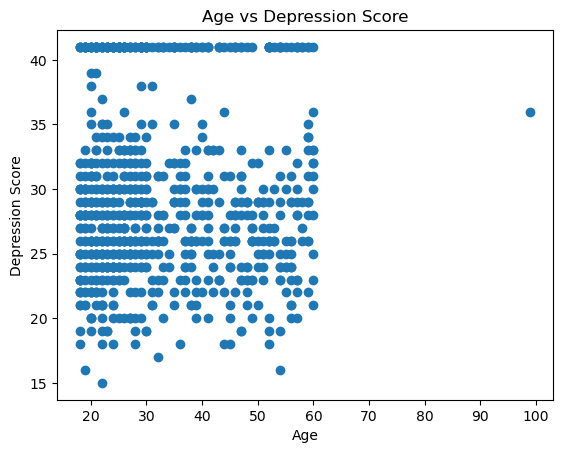

In [29]:
plt.scatter(df['age'], df['drs'])
plt.xlabel("Age")
plt.ylabel("Depression Score")
plt.title("Age vs Depression Score")
plt.show()

In [30]:
corr['drs'].sort_values(ascending=False)

drs                 1.000000
drs_raw             0.956740
emotional_score     0.791876
cognitive_score     0.722970
wellbeing_inv       0.697642
behavioral_score    0.611191
physical_score      0.608030
support_inv         0.593804
sadness             0.583155
overthinking        0.574611
stress              0.563558
anxiety             0.552483
tired               0.551896
overwhelmed         0.519376
mood_swings         0.511093
social_inv          0.467069
coping              0.428274
sleep_risk          0.414219
concentration       0.351991
age                -0.003869
sleep              -0.414219
coping_inv         -0.428274
social             -0.467069
support            -0.593804
wellbeing          -0.697642
social_score       -0.702173
Name: drs, dtype: float64

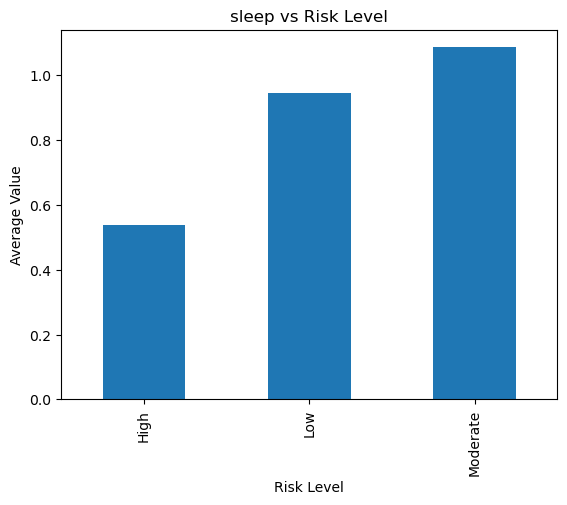

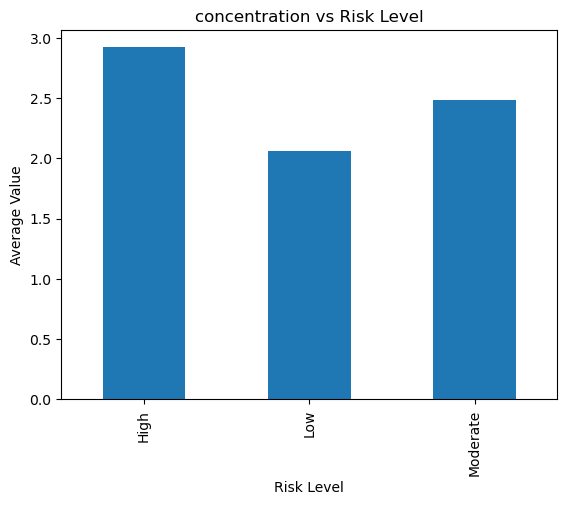

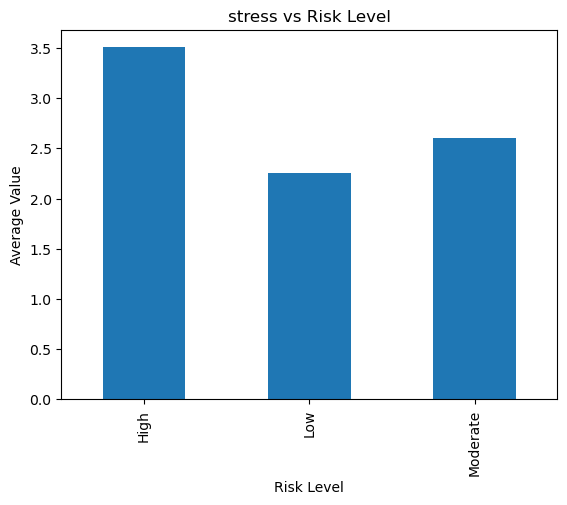

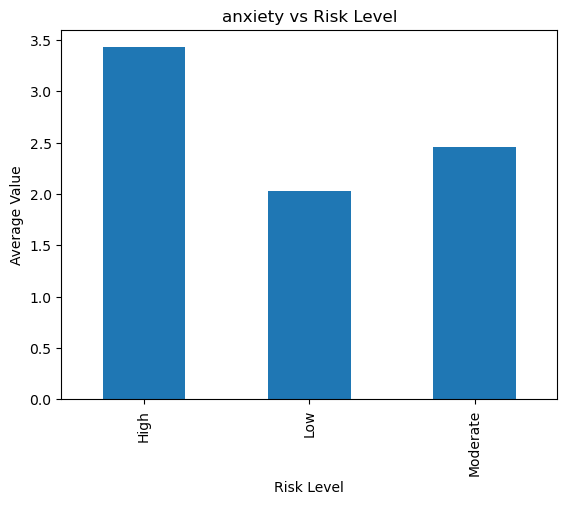

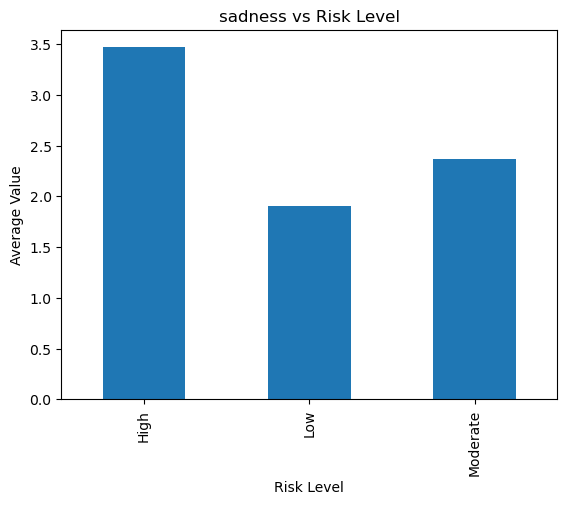

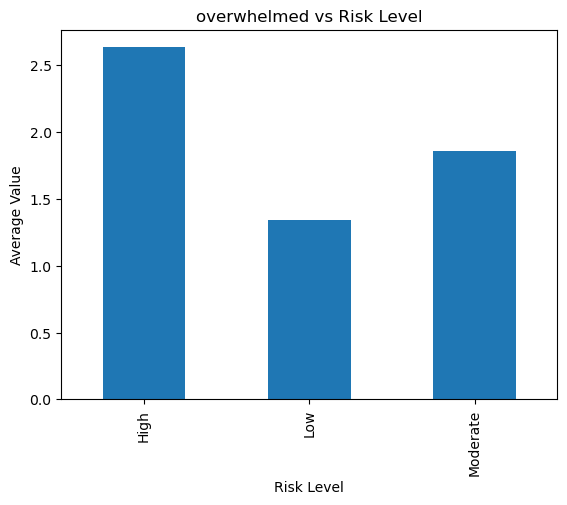

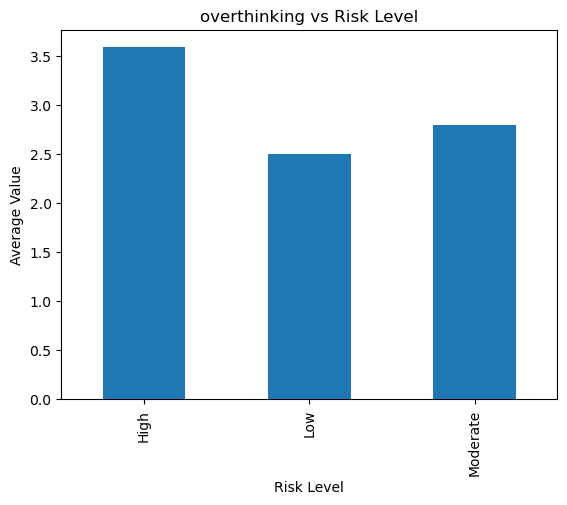

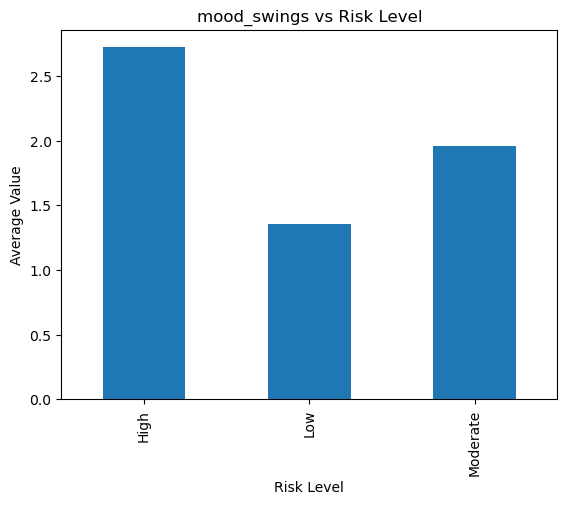

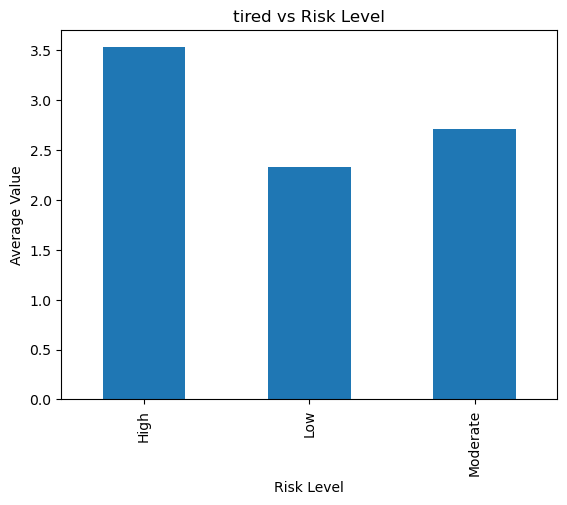

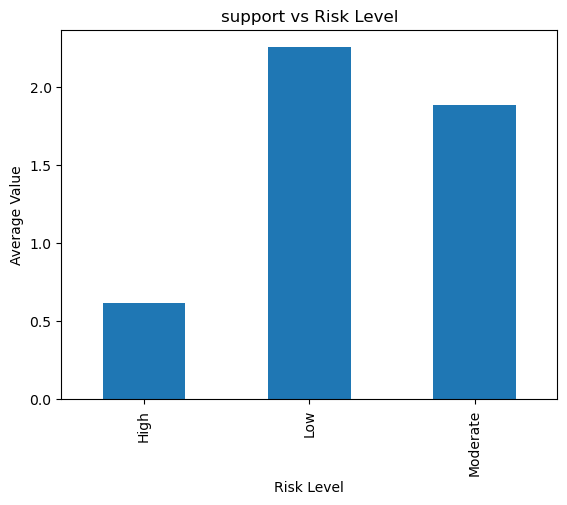

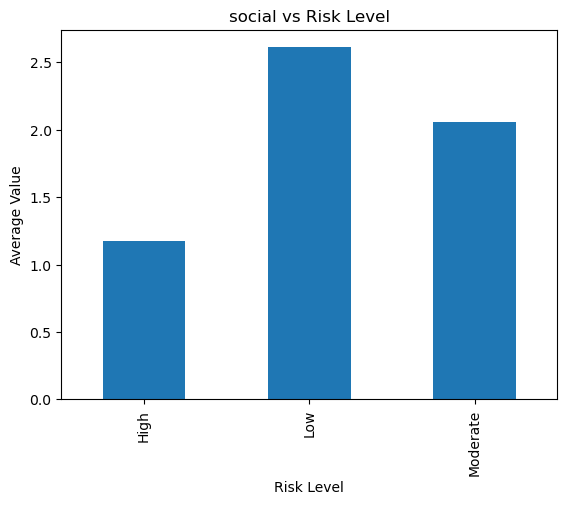

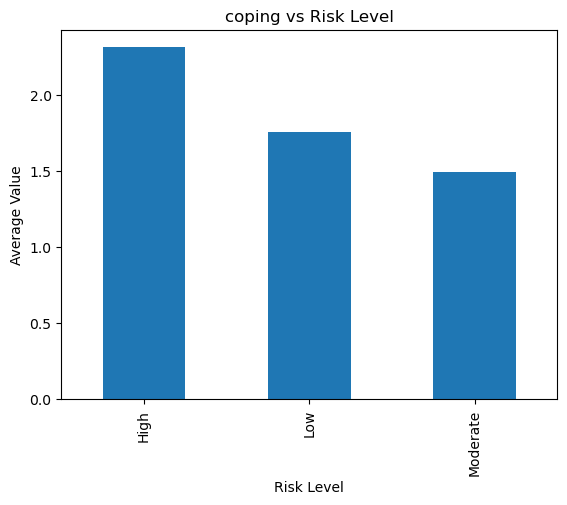

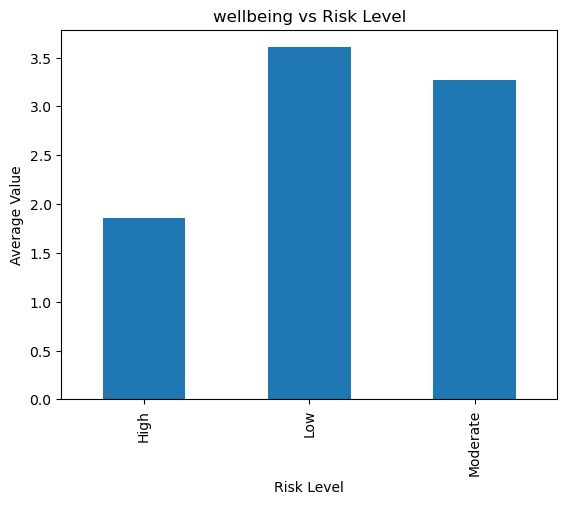

In [31]:
import matplotlib.pyplot as plt

features = [
    'sleep', 'concentration', 'stress', 'anxiety', 'sadness',
    'overwhelmed', 'overthinking', 'mood_swings', 'tired',
    'support', 'social', 'coping', 'wellbeing'
]

for col in features:
    df.groupby('risk_level')[col].mean().plot(kind='bar')
    plt.title(f"{col} vs Risk Level")
    plt.xlabel("Risk Level")
    plt.ylabel("Average Value")
    plt.show()